In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# READ TELESCOPIC CONFIGURATION
df_hole_to_casing = pd.read_csv(r"database\holesize_to_casing.csv")
df_casing_to_hole = pd.read_csv(r"database\casing_to_holesize.csv")

# READ AND NORMALIZE VAM DATA FRAME
from src.database_processor.vam_data_process import get_VAM_OCTG_data
df_vam_data = get_VAM_OCTG_data(r"database\VAM_connections_data.xlsx", basic=True)
print(f"Total unique pipe options: {len(df_vam_data)}")



Total unique pipe options: 764


In [2]:
from src.collapse.api5c3_design import API5C3DesignMethod
from src.collapse.klever_tamano import KleverTamanoMethod
from src.entities.tubular import TubularData
from src.entities.klever_tamano_parameters import DEFAULT_KT_PARAMS
from src.entities.steel_grade import SteelGrade

_api = API5C3DesignMethod()
_kt  = KleverTamanoMethod()


def _build(row):
    grade = SteelGrade(name=str(row['Yield stress (ksi)']),
                       yield_strength=row['Yield stress (ksi)'] * 1000)  # ksi -> psi
    tubular = TubularData(od=row['Size OD (in)'], wt=row['Wall Thickness (in)'], grade=grade)
    return tubular, grade

def get_collapse_regime(row):
    tubular, grade = _build(row)
    return _api.get_regime(tubular, grade)

df_vam_data['Collapse Regime'] = df_vam_data.apply(get_collapse_regime, axis=1)
print(df_vam_data['Collapse Regime'].value_counts())


Collapse Regime
plastic       316
yield         247
transition    137
elastic        64
Name: count, dtype: int64


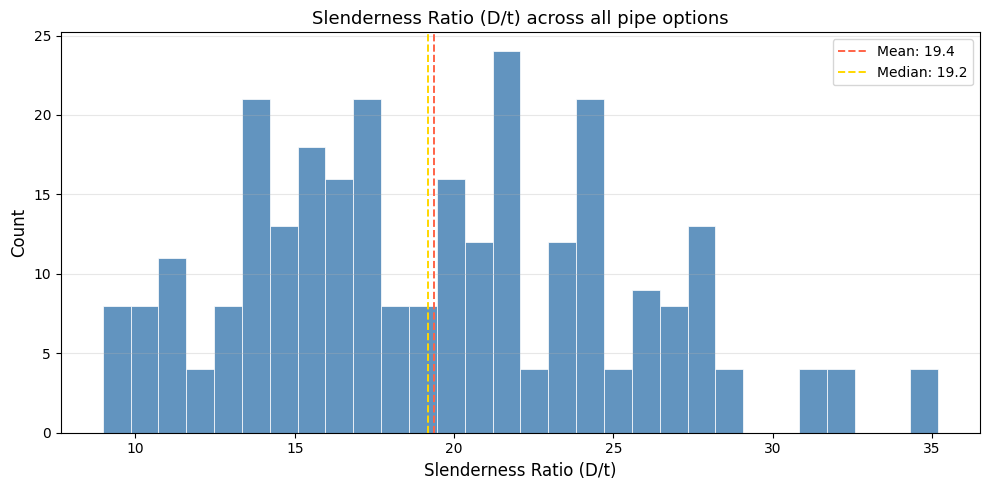

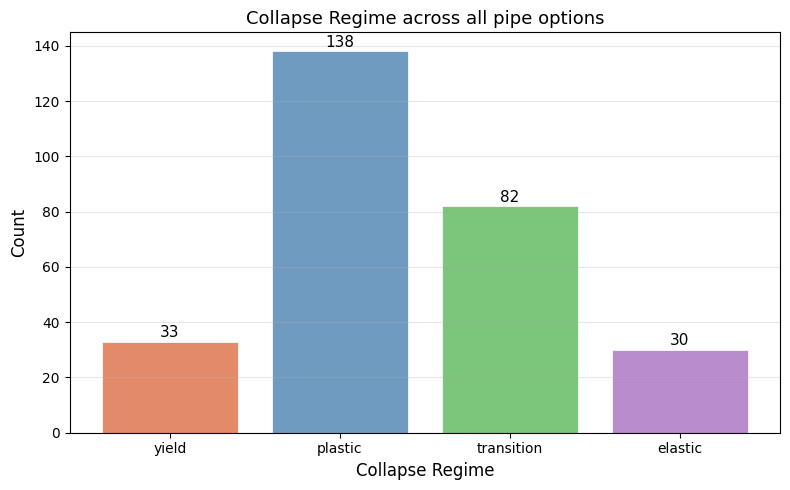

In [ ]:
# print(df_hole_to_casing.columns)

hole_to_casing_filtered = df_hole_to_casing[
    df_hole_to_casing['Hole Size (in)'].between(9, 20, inclusive='both')
].sort_values(['Hole Size (in)', 'Casing OD (in)'], ascending=[False, False])

casing_od_options = hole_to_casing_filtered['Casing OD (in)'].drop_duplicates().sort_values(ascending=False).reset_index(drop=True)
unique_pipes = df_vam_data[df_vam_data['Size OD (in)'].isin(casing_od_options)]

from src.visualization.vis_charts import plot_histogram, plot_bar_chart, REGIME_ORDER, REGIME_COLORS

plot_histogram(unique_pipes['Slenderness Ratio'], title='Slenderness Ratio (D/t) across all pipe options', xlabel='Slenderness Ratio (D/t)')
plot_bar_chart(unique_pipes['Collapse Regime'], title='Collapse Regime across all pipe options',
               xlabel='Collapse Regime', order=REGIME_ORDER, colors=REGIME_COLORS)






In [ ]:
# Plot Size (OD) vs Slenderness Ratio
plt.figure(figsize=(10, 6))
plt.scatter(unique_pipes['Size (OD)'], unique_pipes['Slenderness Ratio'], alpha=0.6, s=50)
plt.xlabel('Size (OD) [inches]')
plt.ylabel('Slenderness Ratio (OD/WT)')
plt.title('Pipe Size vs Slenderness Ratio')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# Histogram of Slenderness Ratio (D/t) across all pipe options
slenderness = df_vam_data['Slenderness Ratio'].drop_duplicates()

fig, ax = plt.subplots(figsize=(10, 5))
n, bins, patches = ax.hist(
    slenderness,
    bins=30,
    color='steelblue',
    edgecolor='white',
    linewidth=0.6,
    alpha=0.85,
)

ax.axvline(slenderness.mean(), color='tomato', linestyle='--', linewidth=1.4,
           label=f'Mean: {slenderness.mean():.1f}')
ax.axvline(slenderness.median(), color='gold', linestyle='--', linewidth=1.4,
           label=f'Median: {slenderness.median():.1f}')

ax.set_xlabel('Slenderness Ratio (D/t)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Distribution of Slenderness Ratio (D/t) — VAM OCTG Pipe Options', fontsize=13)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
